In [2]:
import numpy as np


segs = np.array([  0,    15,    30,    45,  60,
                     75,    90,    105,   120, 
                           135,  150 ,   165,    180,
                                 195,  210,     225,   240, 
                                   255,    270,   285,  300,
                                     315, 330, 345, 360])

TF16 = np.array([   273.15+16,   287.9, 286.9,  286.0,  285.3,  284.6,  283.9 ,  283.5 ,  282.9 , 282.56 ,  282.1 , 281.8 , 
                 281.47, 281.2 ,  280.9 , 280.7 ,   280.5 ,   280.3 ,   280.1 ,    280.0 ,   279.8   
])

T16 = np.array([ 273.15+16, 287.7, 286.7,  285.9, 285.2, 
                284.5,  283.9,   283.4,   282.9,   
                282.5,  282.1,  281.7,  281.4,  
                281.17,  280.9,  280.7,  280.5, 
                  280.3,  280.1,  279.9,  279.8, 
                    279.7,  279.6, 279.5, 279.4])

T17 = np.array([273.15+17,288.6, 287.51,286.59,285.77, 
                285.03,284.38,283.8,283.28,
                282.81,282.39,282.02,281.69,
                281.39,281.12,280.87,280.65,
                280.45,280.27,280.11,279.96,
                279.8,279.7,279.6,279.5])
T18 = np.array([273.15+18, 289.5,288.3,287.3,286.4,
                285.6,284.8,284.2,283.6,
                 283.1, 282.7, 282.3,281.9,
                   281.6, 281.3,281.1, 280.8,
                   280.6,280.4,280.2, 280.1,
                   279.9,279.8,279.7, 279.6])

T19 = np.array([273.15+19,290.3,289.0,287.9,286.9,
                286.1,285.3,284.6,284.0,283.5,282.98,282.6,282.2,
                281.8,281.5,281.2,280.98,280.7,280.5,280.4,
                280.2,280.0,279.9,279.8,279.6
])

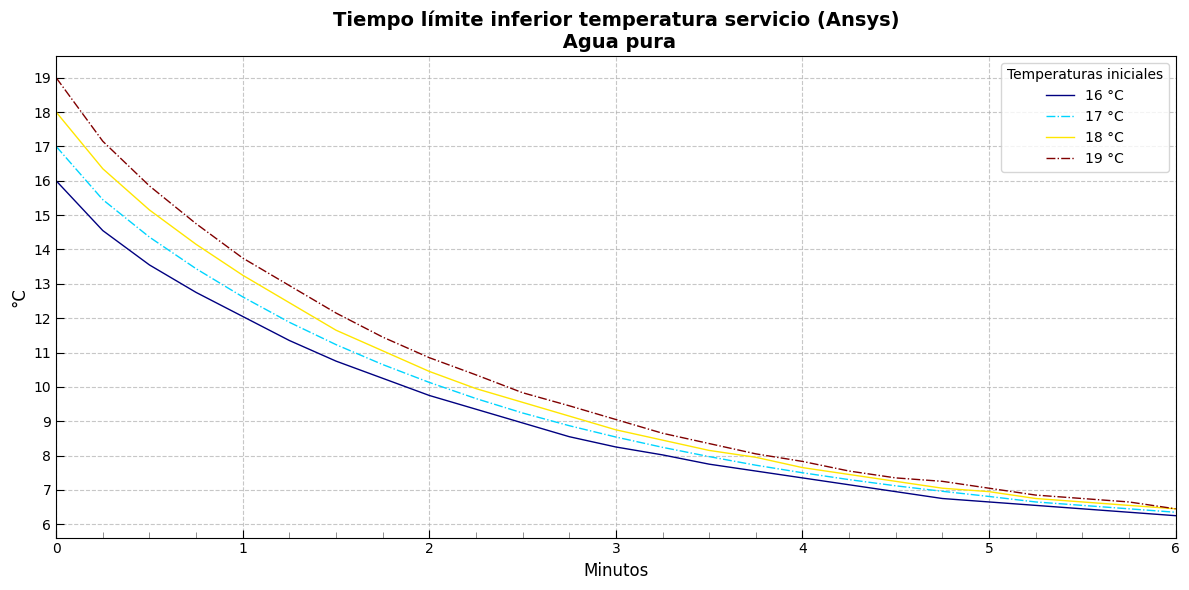

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# =====================================================================
# 1. DATOS DE ENTRADA (Ansys)
# =====================================================================

# Creamos una lista de tuplas (Temperatura_Inicial, Array_de_Datos) para iterar
datos_ansys = [
    (16, T16),
    (17, T17),
    (18, T18),
    (19, T19)
]

# =====================================================================
# 2. GRAFICAR LOS RESULTADOS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6)) 

# Extraemos la cantidad de curvas para el mapa de colores
colores = plt.cm.jet(np.linspace(0, 1, len(datos_ansys)))

# Iteramos sobre los datos usando la misma lógica par/impar que tu referencia
for i, (T_ini_C, T_array) in enumerate(datos_ansys):
    tiempo_minutos = segs / 60
    t_bath_historico = T_array - 273.15
    
    if i % 2 == 0:  
        ax.plot(tiempo_minutos, t_bath_historico, label=f'{T_ini_C} °C', color=colores[i], linewidth=1, linestyle='-')
    else:
        ax.plot(tiempo_minutos, t_bath_historico, label=f'{T_ini_C} °C', color=colores[i], linewidth=1, linestyle='-.')

# Configuraciones de títulos y etiquetas
ax.set_title('Tiempo límite inferior temperatura servicio (Ansys)\n Agua pura', fontsize=14, fontweight='bold')
ax.set_xlabel('Minutos', fontsize=12)
ax.set_ylabel('°C', fontsize=12)

# =====================================================================
# 3. AJUSTE DE EJES (Límites, Ticks Principales y Secundarios)
# =====================================================================
# 1. Límites estrictos: De 0 a 6 minutos
ax.set_xlim(0, 6)

# 2. Eje Y: Marcas principales de 1 en 1 grado
ax.yaxis.set_major_locator(MultipleLocator(1))

# 3. Eje X: 
#    - Marcas principales (con número) cada 1 minuto
ax.xaxis.set_major_locator(MultipleLocator(1))
#    - Marcas menores (ticks pequeños) cada 0.25 minutos (15 segundos)
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

# Hacemos que los ticks menores sean un poco más visibles hacia adentro o afuera
ax.tick_params(which='minor', length=4, color='gray', direction='in')
ax.tick_params(which='major', length=6, direction='in')

# Mostramos la cuadrícula solo para las marcas principales
ax.grid(which='major', linestyle='--', alpha=0.7)

# Colocamos la leyenda (ahora sí funcionará porque agregamos el 'label' en el ax.plot)
ax.legend(loc='upper right', title="Temperaturas iniciales")

plt.tight_layout()
plt.show()